In [9]:
import sqlite3
import pandas as pd

# Mets ici le vrai nom du fichier, par exemple oil_wells.db
db_path = r"C:\Users\zouao\OIL_WELL_MANAGER\OIL_WELL_MANAGER\oil_wells.db"
conn = sqlite3.connect(db_path)

df_prod = pd.read_sql_query("SELECT * FROM productions", conn)
df_incidents = pd.read_sql_query("SELECT * FROM incidents", conn)
df_interv = pd.read_sql_query("SELECT * FROM interventions", conn)
df_wells = pd.read_sql_query("SELECT * FROM wells", conn)
df_sites = pd.read_sql_query("SELECT * FROM sites", conn)

df_prod.head()


,id,well_id,timestamp,flow_rate,pressure,temperature,quantity_produced
0,1,1,2010-01-01 12:00:00,426.44,3143.99,66.59,2210.97
1,2,1,2010-02-01 12:00:00,479.62,4399.82,120.38,512.73
2,3,1,2010-03-01 12:00:00,175.14,3974.18,137.26,3149.62
3,4,1,2010-04-01 12:00:00,419.91,2871.33,62.65,9465.58
4,5,1,2010-05-01 12:00:00,139.57,3485.17,110.63,4667.61


In [8]:
import sqlite3

db_path = r"C:\Users\zouao\OIL_WELL_MANAGER\OIL_WELL_MANAGER\oil_wells.db"
conn = sqlite3.connect(db_path)

# Cette requête te montre TOUTES les tables qui existent vraiment dans ta base
tables = conn.execute("SELECT name FROM sqlite_master WHERE type='table';").fetchall()
print(tables)

[('migrations',), ('sqlite_sequence',), ('sites',), ('wells',), ('teams',), ('interventions',), ('incidents',), ('productions',)]


In [6]:
import sys
print(sys.executable)


c:\Users\zouao\OIL_WELL_MANAGER\OIL_WELL_MANAGER\venv\Scripts\python.exe


In [13]:

import pandas as pd
import numpy as np
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score, 
                             f1_score, classification_report)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

# Pour que les graphiques s'affichent bien dans le notebook
%matplotlib inline
plt.style.use('seaborn-v0_8')

In [14]:
# Recharge proprement les données depuis la base
conn = sqlite3.connect(db_path)

df_prod = pd.read_sql("SELECT * FROM productions", conn)   # nom corrigé !
df_inc  = pd.read_sql("SELECT * FROM incidents", conn)
df_intv = pd.read_sql("SELECT * FROM interventions", conn)
df_wells = pd.read_sql("SELECT * FROM wells", conn)
df_sites = pd.read_sql("SELECT * FROM sites", conn)

conn.close()

# Conversion des dates
df_prod['timestamp'] = pd.to_datetime(df_prod['timestamp'], errors='coerce')
df_inc['date']      = pd.to_datetime(df_inc['date'], errors='coerce')

print(f"Données chargées : {df_prod.shape[0]} lignes de production")

Données chargées : 73152 lignes de production


In [17]:
# Dataset de base
data = df_prod.copy()

# Features temporelles
data['year']       = data['timestamp'].dt.year
data['month']      = data['timestamp'].dt.month
data['day_of_week']= data['timestamp'].dt.dayofweek

# Infos puits (version qui marche à tous les coups)
if 'well_id' in df_wells.columns:
    data = data.merge(df_wells[['well_id', 'depth', 'status']], on='well_id', how='left')
elif 'id' in df_wells.columns:
    data = data.merge(df_wells[['id', 'depth', 'status']], 
                      left_on='well_id', right_on='id', how='left')
    data = data.drop('id auk', axis=1, errors='ignore')
else:
    print("Colonne d'identifiant puits non trouvée !")

print("Merge avec wells OK")

# Encodage statut
le = LabelEncoder()
data['status_code'] = le.fit_transform(data['status'].fillna('unknown'))

# Incidents dans les 30 jours précédents
def count_incidents_last_30(row):
    well, ts = row['well_id'], row['timestamp']
    if pd.isna(ts): return 0
    mask = (df_inc['well_id'] == well) & \
           (df_inc['date'] >= ts - pd.Timedelta(days=30)) & \
           (df_inc['date'] < ts)
    return len(df_inc[mask])

data['incidents_last_30d'] = data.apply(count_incidents_last_30, axis=1)

# Target classification : incident dans les 30 jours suivants
def has_incident_next_30(row):
    well, ts = row['well_id'], row['timestamp']
    if pd.isna(ts): return 0
    mask = (df_inc['well_id'] == well) & \
           (df_inc['date'] > ts) & \
           (df_inc['date'] <= ts + pd.Timedelta(days=30))
    return 1 if len(df_inc[mask]) > 0 else 0

data['incident_next_30d'] = data.apply(has_incident_next_30, axis=1)

print("Feature engineering terminé !")
data[['well_id', 'quantity_produced', 'incidents_last_30d', 'incident_next_30d']].head()

Merge avec wells OK
Feature engineering terminé !


,well_id,quantity_produced,incidents_last_30d,incident_next_30d
0,1,2210.97,0,0
1,1,512.73,0,0
2,1,3149.62,0,0
3,1,9465.58,0,0
4,1,4667.61,0,0


In [16]:
print("Colonnes dans df_wells :")
print(df_wells.columns.tolist())
print("\nAperçu des 3 premières lignes :")
display(df_wells.head(3))

Colonnes dans df_wells :
['id', 'site_id', 'name', 'depth', 'status']

Aperçu des 3 premières lignes :


,id,site_id,name,depth,status
0,1,1,Well-FL925,4733.93,active
1,2,1,Well-CY575,3480.56,inactive
2,3,1,Well-YW586,4031.85,maintenance


In [18]:
features = ['flow_rate', 'pressure', 'temperature', 'depth',
            'incidents_last_30d', 'status_code', 'year', 'month', 'day_of_week']

target_reg = 'quantity_produced'
target_clf = 'incident_next_30d'

# Datasets propres
df_reg = data.dropna(subset=[target_reg] + features).copy()
df_clf = data.dropna(subset=[target_clf] + features).copy()

print(f"Dataset régression     : {df_reg.shape}")
print(f"Dataset classification : {df_clf.shape}")
print(f"Features utilisées ({len(features)}): {features}")

Dataset régression     : (73152, 16)
Dataset classification : (73152, 16)
Features utilisées (9): ['flow_rate', 'pressure', 'temperature', 'depth', 'incidents_last_30d', 'status_code', 'year', 'month', 'day_of_week']


Entraînement du modèle de RÉGRESSION (prédiction de quantity_produced)...

RÉSULTATS RÉGRESSION
R²  : -0.027
RMSE: 2902.68
MAE : 2511.55



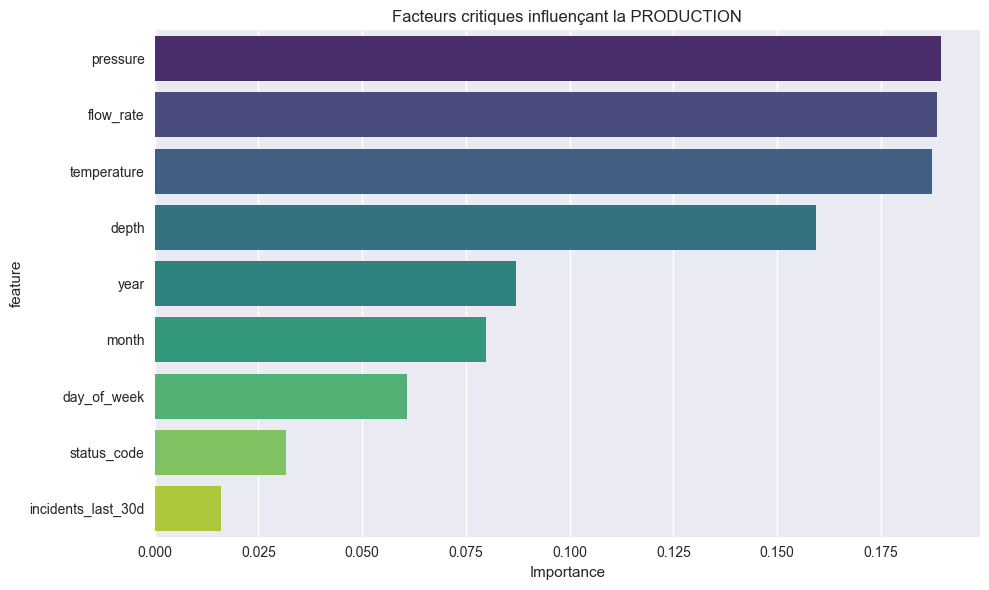

In [20]:
print("Entraînement du modèle de RÉGRESSION (prédiction de quantity_produced)...\n")

X_reg = df_reg[features]
y_reg = df_reg[target_reg]

X_train_r, X_Ptest_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

rf_reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_r, y_train_r)
y_pred_r = rf_reg.predict(X_test_r)

print("RÉSULTATS RÉGRESSION")
print(f"R²  : {r2_score(y_test_r, y_pred_r):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_r, y_pred_r)):.2f}")   # ← ligne corrigée
print(f"MAE : {mean_absolute_error(y_test_r, y_pred_r):.2f}\n")

# Importance des features
importances_reg = pd.DataFrame({
    'feature': features,
    'importance': rf_reg.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importances_reg, x='importance', y='feature', palette='viridis')
plt.title('Facteurs critiques influençant la PRODUCTION')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

Entraînement du modèle de CLASSIFICATION (risque d'incident dans 30j)...

RÉSULTATS CLASSIFICATION
Accuracy  : 0.843
Precision : 0.000
Recall    : 0.000
F1-score  : 0.000

               precision    recall  f1-score   support

Pas de risque       0.84      1.00      0.91     12338
 Risque élevé       0.00      0.00      0.00      2293

     accuracy                           0.84     14631
    macro avg       0.42      0.50      0.46     14631
 weighted avg       0.71      0.84      0.77     14631



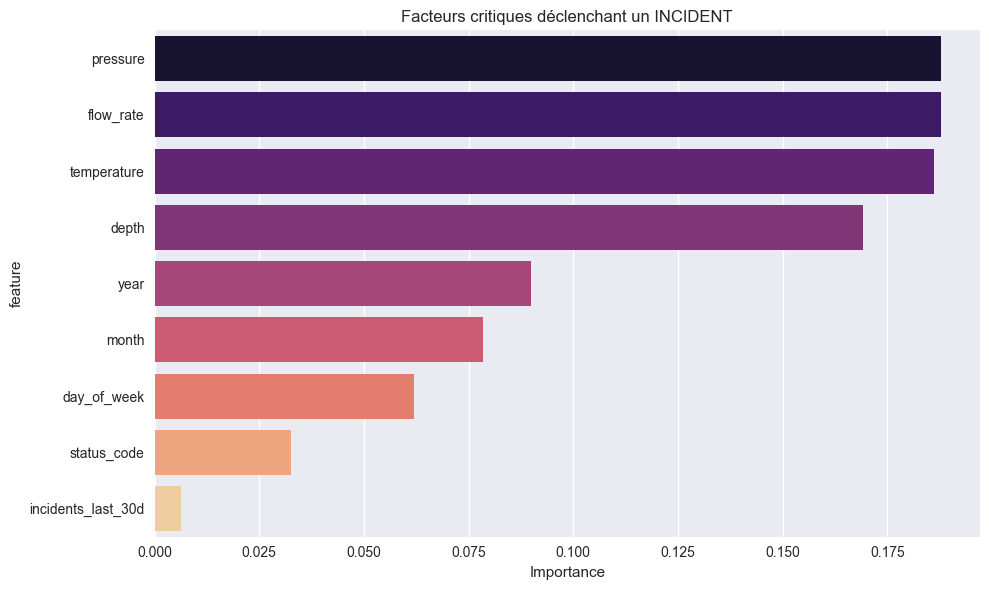

In [21]:
print("Entraînement du modèle de CLASSIFICATION (risque d'incident dans 30j)...\n")

X_clf = df_clf[features]
y_clf = df_clf[target_clf]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

rf_clf = RandomForestClassifier(
    n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)
rf_clf.fit(X_train_c, y_train_c)
y_pred_c = rf_clf.predict(X_test_c)

print("RÉSULTATS CLASSIFICATION")
print(f"Accuracy  : {accuracy_score(y_test_c, y_pred_c):.3f}")
print(f"Precision : {precision_score(y_test_c, y_pred_c):.3f}")
print(f"Recall    : {recall_score(y_test_c, y_pred_c):.3f}")
print(f"F1-score  : {f1_score(y_test_c, y_pred_c):.3f}\n")
print(classification_report(y_test_c, y_pred_c, 
                          target_names=['Pas de risque', 'Risque élevé']))

# Importance des features
importances_clf = pd.DataFrame({
    'feature': features,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importances_clf, x='importance', y='feature', palette='magma')
plt.title('Facteurs critiques déclenchant un INCIDENT')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [22]:
# 4. Sauvegarde des modèles (prêts à être utilisés dans l'app Flask)
# ===================================================================
joblib.dump(rf_reg, 'model_production_predictor.pkl')
joblib.dump(rf_clf, 'model_incident_risk_predictor.pkl')
joblib.dump(features, 'model_features_list.pkl')  # important pour l'app !

print("Modèles sauvegardés :")
print("→ model_production_predictor.pkl")
print("→ model_incident_risk_predictor.pkl")
print("→ model_features_list.pkl")
print("\nÉtape 3 terminée avec succès !")

Modèles sauvegardés :
→ model_production_predictor.pkl
→ model_incident_risk_predictor.pkl
→ model_features_list.pkl

Étape 3 terminée avec succès !
